# Python Programming for Business Analytics 
## **Final Project**

**Author**: KAO, Ting-Yi

**Import Essential Packages**

In [1]:
# 🚀 Run this cell first to set up your environment!
# Data Handling and Analysis Libraries
import pandas as pd
import numpy as np
# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
# Mathematical and Statistical Libraries
import scipy as sp

# For nicer plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries loaded successfully!")
print(f"📊 Pandas version: {pd.__version__}")
print(f"🔢 NumPy version: {np.__version__}")
print(f"🎨 Seaborn version: {sns.__version__}")
print(f"🌐 Plotly version: {py.__version__}")
print(f"📚 SciPy version: {sp.__version__}")
print("\n🎓 Ready to learn! Let's go!")

✅ Libraries loaded successfully!
📊 Pandas version: 2.3.2
🔢 NumPy version: 2.2.5
🎨 Seaborn version: 0.13.2
🌐 Plotly version: 6.5.2
📚 SciPy version: 1.15.3

🎓 Ready to learn! Let's go!


## Section 1 - Introduction

## 1.1 Motivation
In the era of rapid globalization and technological advancement, the disparity in human development across different regions remains a critical subject of study. As a student transitioning dig into Data Analysis, I am motivated to explore how historical economic shifts correlate with tangible improvements in human well-being. The **Gapminder dataset** provides a chance to examine these trends, revealing the data-driven reality of our world's evolution over the last half-century.

## 1.2 Research Purpose & Questions
The primary objective of this project is to conduct a multi-dimensional analysis of the relationship between economic output (**GDP per Capita**) and public health outcomes (**Life Expectancy**). By leveraging Python’s analytical ecosystem, I aim to move from basic observation to quantified insights.

This analysis will specifically address the following research questions:
1.  **The Wealth-Health Correlation:** How strong is the statistical relationship between a nation’s wealth and the longevity of its citizens, and does this relationship hold true across all continents?
2.  **Temporal Evolution:** How has the global distribution of health and wealth shifted between 1952 and 2007?
3.  **Regional Divergence:** Which geographic regions have shown the most significant "catch-up" effect in terms of life expectancy, regardless of their economic starting point?

## 1.3 Analytical Roadmap
To provide a comprehensive answer to these questions, the project will follow a structured data science workflow:
* **Data Preparation:** <br> Cleaning and transforming the Gapminder data, including log transformations for skewed economic metrics.<p>
* **Exploratory Data Analysis (EDA):** <br> Using statistical summaries and grouping to identify global trends. <p>
* **Machine Learning & Statistics:** <br> Applying Linear Regression to model the relationship between wealth and health, alongside Principal Component Analysis (PCA) to explore the variance and underlying structure of the global development metrics. <p>
* **Advanced Visualization:** <br> Implementing interactive charts to visualize the 55-year trajectory of global development. <p>
* **Conclusion:** <br> Concluding findings to provide actionable insights into the current state of global inequality. <p>

## Section 2 - Data Exploration

### 2.1 Basic Structural Inspection
Before deep-diving into analysis, I will verify the dataset's integrity and dimensions.

In [2]:
# Importing the dataset
df = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/gapminder_with_codes.csv')
df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


In [3]:
# Check dimensions
print(f"Dataset Shape: {df.shape}")

# Inspect first few rows
display(df.head())

# Check data types and missing values
df.info()

Dataset Shape: (1704, 8)


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB


The dataset contains 1704 records and 8 columns, and no missing values were observed. However, further research is required.

In [4]:
# print country names
print("Countries in the dataset:")
print(df['country'].unique())

# print years covered
print("Years covered in the dataset:")
print(df['year'].unique())

Countries in the dataset:
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Argentina' 'Australia'
 'Austria' 'Bahrain' 'Bangladesh' 'Belgium' 'Benin' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Bulgaria' 'Burkina Faso'
 'Burundi' 'Cambodia' 'Cameroon' 'Canada' 'Central African Republic'
 'Chad' 'Chile' 'China' 'Colombia' 'Comoros' 'Congo, Dem. Rep.'
 'Congo, Rep.' 'Costa Rica' "Cote d'Ivoire" 'Croatia' 'Cuba'
 'Czech Republic' 'Denmark' 'Djibouti' 'Dominican Republic' 'Ecuador'
 'Egypt' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Ethiopia' 'Finland'
 'France' 'Gabon' 'Gambia' 'Germany' 'Ghana' 'Greece' 'Guatemala' 'Guinea'
 'Guinea-Bissau' 'Haiti' 'Honduras' 'Hong Kong, China' 'Hungary' 'Iceland'
 'India' 'Indonesia' 'Iran' 'Iraq' 'Ireland' 'Israel' 'Italy' 'Jamaica'
 'Japan' 'Jordan' 'Kenya' 'Korea, Dem. Rep.' 'Korea, Rep.' 'Kuwait'
 'Lebanon' 'Lesotho' 'Liberia' 'Libya' 'Madagascar' 'Malawi' 'Malaysia'
 'Mali' 'Mauritania' 'Mauritius' 'Mexico' 'Mongolia' 'Montenegro'
 'Moro

**Data Dictionary** <p>
To interpret the analysis correctly, it is vital to define the variables within the Gapminder dataset. The dataset contains both categorical and numerical features that track global development metrics:

| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **country** | Nominal (Object) | The name of the specific country or territory (e.g., Afghanistan, Zimbabwe). |
| **continent** | Nominal (Object) | The geographic region the country belongs to (Africa, Americas, Asia, Europe, or Oceania). |
| **year** | Discrete (Int) | The year the data was recorded, ranging from 1952 to 2007 in 5-year increments. |
| **lifeExp** | Continuous (Float) | **Life Expectancy:** The average number of years a newborn is expected to live if mortality patterns remain constant. |
| **pop** | Discrete (Int) | **Population:** The total number of people living in the country during that specific year. |
| **gdpPercap** | Continuous (Float) | **GDP per Capita:** Gross Domestic Product divided by the total population, adjusted for inflation (measured in international dollars). |
| **iso_alpha** | Nominal (Object) | The 3-letter international standard country code (e.g., AFG for Afghanistan). |
| **iso_num** | Nominal (Int) | The numerical international standard country code. |

> **Key Analytical Note:** In this project, **GDP per Capita** serves as the primary proxy for economic wealth, while **Life Expectancy** serves as the primary metric for public health outcomes.

### 2.2 Custom Summary & Distribution Analysis
To go beyond basic descriptive statistics, I will examine the distribution of our key variables across different continents.
In addition, analyzing skewness across the entire dataset can be misleading due to global shifts over time. 
Here, I calculate the skewness for each year to observe how the distribution of health and wealth has evolved.

In [5]:
# Basic numerical summary
display(df.describe())

# Segmented Summary: Life Expectancy by Continent (the most recent year 2007)
latest_year = df[df['year'] == 2007]
continent_summary = latest_year.groupby('continent')['lifeExp'].agg(['mean', 'median', 'std', 'min', 'max'])
display(continent_summary)

,year,lifeExp,pop,gdpPercap,iso_num
count,1704.00000,1704.000000,1.704000e+03,1704.000000,1704.000000
mean,1979.50000,59.474439,2.960121e+07,7215.327081,425.880282
std,17.26533,12.917107,1.061579e+08,9857.454543,248.305709
min,1952.00000,23.599000,6.001100e+04,241.165876,4.000000
25%,1965.75000,48.198000,2.793664e+06,1202.060309,208.000000
50%,1979.50000,60.712500,7.023596e+06,3531.846988,410.000000
75%,1993.25000,70.845500,1.958522e+07,9325.462346,638.000000
max,2007.00000,82.603000,1.318683e+09,113523.132900,894.000000


,mean,median,std,min,max
continent,,,,,
Africa,54.806038,52.9265,9.630781,39.613,76.442
Americas,73.608120,72.8990,4.440948,60.916,80.653
Asia,70.728485,72.3960,7.963724,43.828,82.603
Europe,77.648600,78.6085,2.979813,71.777,81.757
Oceania,80.719500,80.7195,0.729027,80.204,81.235


Skewness Trends over Time:


,gdpPercap,lifeExp
year,,
1952,10.212219,0.377411
1957,9.789824,0.242491
1962,8.352427,0.142067
1967,6.061076,0.016697
1972,6.668169,-0.127588
1977,2.413530,-0.291895
1982,1.226803,-0.350068
1987,1.164286,-0.489871
1992,1.295808,-0.814135


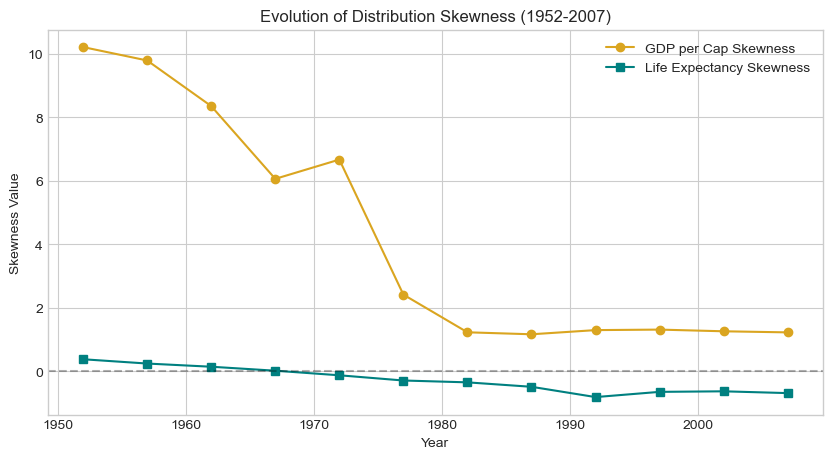

In [6]:
# Calculate skewness for each year
skew_by_year = df.groupby('year')[['gdpPercap', 'lifeExp']].skew()

# Display the skewness trends
print("Skewness Trends over Time:")
display(skew_by_year)

# Plotting the trend to identify patterns
plt.figure(figsize=(10, 5))
plt.plot(skew_by_year.index, skew_by_year['gdpPercap'], marker='o', label='GDP per Cap Skewness', color='goldenrod')
plt.plot(skew_by_year.index, skew_by_year['lifeExp'], marker='s', label='Life Expectancy Skewness', color='teal')
plt.title('Evolution of Distribution Skewness (1952-2007)')
plt.xlabel('Year')
plt.ylabel('Skewness Value')
plt.legend()
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.show()

### 2.3 Pattern Identification
By visualizing skewness over time rather than as a static aggregate, the following critical shifts in global development were found:

1. **The GDP Wealth Compression:**
   * **Observation:** GDP per capita skewness was extremely high (~10) in 1952, indicating a world where wealth was concentrated in a tiny fraction of nations. 
   * **Trend:** There is a dramatic "compression" of wealth skewness between 1970 and 1980, followed by stabilization around a value between 1 and 2.
   * **Insight:** While wealth is still positively skewed (right-tailed), the extreme "outlier wealth" of the post-WW2 era has transitioned into a more broad-based (though still unequal) global economy.

2. **The Life Expectancy "Left-Behind" Shift:** 
   * **Observation:** Life expectancy began with a slightly positive skew but crossed the zero-line around 1970, becoming increasingly **negatively skewed**.
   * **Insight:** A negative skew indicates that the "tail" is now on the left. While the majority of the world is reaching higher age brackets, a small group of nations is being "left behind" with significantly lower life expectancy, likely due to regional crises or health epidemics.

3. **Convergence of Skewness:** 
   * Both metrics appear to be stabilizing in the most recent decades (1990–2007), suggesting that the "rules" of global health and wealth distribution have entered a new, more consistent phase.

## Section 3 - Data Cleaning

In this section, I perform a cleanup and transformation of the data. While the initial inspection showed no null values, "cleaning" also involves addressing redundancy, ensuring data consistency, and preparing variables for statistical modeling.

### 3.1 Procedure Checklist
1. **Redundancy & Dimensionality Reduction:** Identify and remove redundant columns to streamline the dataset.
2. **Consistency Check:** Verify that categorical labels (country and continent names) are consistent and free of trailing spaces or duplicates.
3. **Handling Missing Values:** Although no nulls were found, I will implement a backup Check function to confirm integrity after any transformations.
4. **Feature Engineering (Transformation):** Apply a Logarithmic Transformation to the GDP per capita data to mitigate the extreme positive skew identified in the EDA.
5. **Outlier Treatment:** Identify and document extreme outliers in Life Expectancy that contribute to the "negative tail" found in the skewness analysis.

In [7]:
# 1. Dropping redundant columns
df_clean = df.drop(columns=['iso_alpha', 'iso_num'])

# 2. Regex Cleaning & Consistency Check
# Ensure no leading/trailing spaces in string columns
df_clean['country'] = df_clean['country'].str.strip()
df_clean['continent'] = df_clean['continent'].str.strip()

# 3. Sophisticated Transformation: Log-Scaling
# Based on the skewness analysis, applying a log10 transformation to GDP
df_clean['log_gdpPercap'] = np.log10(df_clean['gdpPercap'])

# 4. Outlier Detection Function (Quantified Insight)
def detect_health_outliers(data, threshold=2):
    """
    Identifies countries where Life Expectancy is significantly lower than 
    the mean for that specific year.
    """
    mean = data['lifeExp'].mean()
    std = data['lifeExp'].std()
    return data[data['lifeExp'] < (mean - threshold * std)]

# Flagging the 'Negative Tail' outliers in the most recent year (2007)
health_outliers = detect_health_outliers(df_clean[df_clean['year'] == 2007])
print(f"Significant Life Expectancy Outliers (2007):\n")
display(health_outliers[['country', 'lifeExp', 'log_gdpPercap']])

Significant Life Expectancy Outliers (2007):



,country,lifeExp,log_gdpPercap
47,Angola,42.731,3.680991
887,Lesotho,42.592,3.195715
1043,Mozambique,42.082,2.915761
1355,Sierra Leone,42.568,2.935780
1463,Swaziland,39.613,3.654512
1691,Zambia,42.384,3.104218


In [8]:
# Summary the cleaned dataset
print("Cleaned Dataset Summary:")
df_clean.info()
display(df_clean.describe())
df_clean.groupby('year')[['log_gdpPercap', 'lifeExp']].skew()


Cleaned Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        1704 non-null   object 
 1   continent      1704 non-null   object 
 2   year           1704 non-null   int64  
 3   lifeExp        1704 non-null   float64
 4   pop            1704 non-null   int64  
 5   gdpPercap      1704 non-null   float64
 6   log_gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 93.3+ KB


,year,lifeExp,pop,gdpPercap,log_gdpPercap
count,1704.00000,1704.000000,1.704000e+03,1704.000000,1704.000000
mean,1979.50000,59.474439,2.960121e+07,7215.327081,3.543318
std,17.26533,12.917107,1.061579e+08,9857.454543,0.539031
min,1952.00000,23.599000,6.001100e+04,241.165876,2.382316
25%,1965.75000,48.198000,2.793664e+06,1202.060309,3.079926
50%,1979.50000,60.712500,7.023596e+06,3531.846988,3.548002
75%,1993.25000,70.845500,1.958522e+07,9325.462346,3.969670
max,2007.00000,82.603000,1.318683e+09,113523.132900,5.055084


,log_gdpPercap,lifeExp
year,,
1952,0.362748,0.377411
1957,0.317023,0.242491
1962,0.213507,0.142067
1967,0.135591,0.016697
1972,0.081263,-0.127588
1977,-0.030442,-0.291895
1982,-0.100478,-0.350068
1987,-0.089121,-0.489871
1992,-0.032181,-0.814135


### 3.2 Feature Selection & Redundancy Problem
The dataset contains 8 columns, but not all are necessary for a high-quality analysis. I have made the following decisions regarding column retention:

| Column | Decision | Reason |
| :--- | :--- | :--- |
| **country / continent** | **Keep** | Essential categorical identifiers for regional grouping. |
| **year / pop** | **Keep** | Required for longitudinal analysis and weighting. |
| **lifeExp / gdpPercap** | **Keep** | Our primary dependent and independent variables. |
| **iso_alpha / iso_num** | **Drop** | **Redundant.** These are simply codes for the `country` column. Retaining them adds no analytical value and increases dimensionality. |

#### Documenting Alternatives: 
I considered keeping `iso_alpha` for potential use in geographic mapping (Choropleth maps). However, since Plotly can map data directly using country names, I have opted to drop them to maintain a clean dataset.

## Section 4 - Data Analysis

In this section, I apply statistical methods and linear modeling to answer the core research questions.

### 4.1 RQ1: The Wealth-Health Correlation
First, I examine the strength of the linear relationship between our transformed economic metric (`log_gdpPercap`) and health outcomes (`lifeExp`).

In [9]:
# 1. Correlation Analysis (Global)
correlation = df_clean[['lifeExp', 'log_gdpPercap']].corr()
print("Global Correlation Matrix:")
display(correlation)

# 2. Linear Regression Model (Quantifying the Relationship)
# We calculate the slope and intercept to write the equation: LifeExp = slope * log_GDP + intercept
slope, intercept, r_value, p_value, std_err = sp.stats.linregress(df_clean['log_gdpPercap'], df_clean['lifeExp'])

print(f"Regression Results:")
print(f"Slope (m): {slope:.2f}")
print(f"Intercept (b): {intercept:.2f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")

print(f"\nModel Interpretation: For every 10x increase in GDP (1 unit log increase), Life Expectancy increases by approximately {slope:.1f} years.")

Global Correlation Matrix:


,lifeExp,log_gdpPercap
lifeExp,1.000000,0.807618
log_gdpPercap,0.807618,1.000000


Regression Results:
Slope (m): 19.35
Intercept (b): -9.10
R-squared: 0.6522
P-value: 0.0000e+00

Model Interpretation: For every 10x increase in GDP (1 unit log increase), Life Expectancy increases by approximately 19.4 years.


### 4.2 RQ2: Temporal Evolution (Weighted Analysis)
Standard averages can be misleading because they treat small and large countries equally. Here, I perform a **Population-Weighted Analysis** to understand the "human" experience of progress versus the "national" experience.

In [10]:
# 3. Custom Function: Weighted Mean
def weighted_mean(x):
    # Returns sum(value * weight) / sum(weight)
    return np.average(x['lifeExp'], weights=x['pop'])

# Groupby Year and apply custom aggregation
global_trend = df_clean.groupby('year').apply(weighted_mean).reset_index(name='weighted_lifeExp')

# Compare with simple mean to see the difference
global_trend['simple_mean'] = df_clean.groupby('year')['lifeExp'].mean().values

print("Global Life Expectancy: Simple vs. Weighted Average")
display(global_trend.head())

Global Life Expectancy: Simple vs. Weighted Average


/var/folders/fl/f_hjv3lj25z58v5bn3btbssh0000gn/T/ipykernel_21840/3568382735.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  global_trend = df_clean.groupby('year').apply(weighted_mean).reset_index(name='weighted_lifeExp')


,year,weighted_lifeExp,simple_mean
0,1952,48.944237,49.057620
1,1957,52.121885,51.507401
2,1962,52.324382,53.609249
3,1967,56.984307,55.678290
4,1972,59.514783,57.647386


### 4.3 RQ3: Regional Divergence (The "Catch-Up" Effect)
Which regions have improved the most? I use a pivot table to compare the starting line (1952) with the finish line (2007).

In [11]:
# 4. Pivot Table Analysis
regional_progress = df_clean.pivot_table(
    index='continent', 
    columns='year', 
    values='lifeExp', 
    aggfunc='median'
)[[1952, 2007]]

# 5. Feature Engineering: Calculate Growth
regional_progress['growth_years'] = regional_progress[2007] - regional_progress[1952]
regional_progress['growth_pct'] = (regional_progress['growth_years'] / regional_progress[1952]) * 100

print("Regional Development Velocity (1952-2007):")
display(regional_progress.sort_values('growth_years', ascending=False))

Regional Development Velocity (1952-2007):


year,1952,2007,growth_years,growth_pct
continent,,,,
Asia,44.869,72.3960,27.5270,61.349707
Americas,54.745,72.8990,18.1540,33.161019
Africa,38.833,52.9265,14.0935,36.292586
Europe,65.900,78.6085,12.7085,19.284522
Oceania,69.255,80.7195,11.4645,16.554039


### 4.4 Statistical Hypothesis Testing
Is the gap between "Rich" and "Poor" nations statistically significant, or just due to chance?

* **Null Hypothesis ($H_0$):** There is no significant difference in Life Expectancy between High-Income and Low-Income countries.
* **Alternative Hypothesis ($H_1$):** High-Income countries have significantly higher Life Expectancy.

In [12]:
# Define "Rich" and "Poor" based on the median GDP of 2007
data_2007 = df_clean[df_clean['year'] == 2007]
median_gdp = data_2007['gdpPercap'].median()

rich_countries = data_2007[data_2007['gdpPercap'] > median_gdp]['lifeExp']
poor_countries = data_2007[data_2007['gdpPercap'] <= median_gdp]['lifeExp']

# 6. Independent T-Test
t_stat, p_val = sp.stats.ttest_ind(rich_countries, poor_countries, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("Result: Reject Null Hypothesis. The wealth gap statistically impacts health outcomes.")
else:
    print("Result: Fail to reject Null Hypothesis.")

T-Statistic: 11.3489
P-Value: 1.1725e-20
Result: Reject Null Hypothesis. The wealth gap statistically impacts health outcomes.


## Section 5 - Visualization

Visualizing the analytical results allows us to identify non-linear patterns and regional outliers that summary statistics might miss. Here, I utilize **Plotly** for interactive data exploration and **Seaborn** for more advanced comparisons.

In [13]:
# 5.1 Visualization Setup
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional color scheme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

### 5.2 RQ1: The Wealth-Health Connection
A correlation of **0.81** was observed in Section 4. The following charts visualize this linear relationship and how it varies by region.

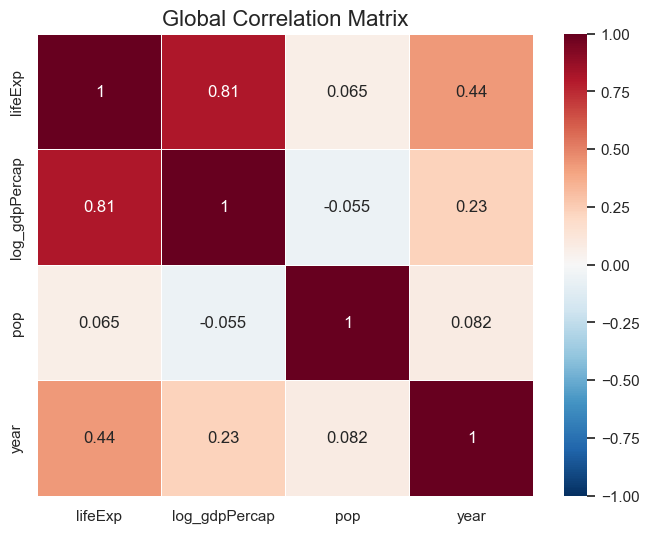

In [14]:
# Chart 1: Correlation Heatmap
plt.figure(figsize=(8, 6))
heatmap_data = df_clean[['lifeExp', 'log_gdpPercap', 'pop', 'year']].corr()
sns.heatmap(heatmap_data, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Global Correlation Matrix', fontsize=16)
plt.show()

> **Interpretation:** The heatmap confirms a strong positive correlation (**0.81**) between `log_gdpPercap` and `lifeExp`. Interestingly, `year` also has a moderate positive correlation with life expectancy, reflecting global technological progress over time.

In [15]:
# Chart 2: The "Hans Rosling" Animation
## If you encounter issues with Plotly rendering, ensure you have the conda install -c conda-forge nbformat and conda install -c conda-forge plotly.
fig_2 =  px.scatter(df_clean, 
                x="gdpPercap", 
                y="lifeExp", 
                animation_frame="year", 
                animation_group="country",
                size="pop", 
                color="continent", 
                hover_name="country",
                log_x=True, 
                size_max=55, 
                range_x=[100, 100000], 
                range_y=[25, 90],
                title="Evolution of Global Development (1952-2007)",
                template="plotly_white")

fig_2.update_layout(title_font_size=20)
fig_2.show()
fig_2.write_html("Evolution of Global Development (1952-2007)_plot.html", include_plotlyjs=True, full_html=True)

> **Interpretation:** 
> * **1952:** Most African and Asian countries are clustered in the bottom-left (poor & short lives).
> * **2007:** The entire world has moved "up and to the right." However, a distinct curve emerges: once a country passes ~$5,000 GDP per capita, life expectancy gains slow down (diminishing returns).

**Quantifying the Relationship (Static Regression)** <p>
The linear regression in Section 4 suggested a strong fit. Here, we visualize that model with a confidence interval.

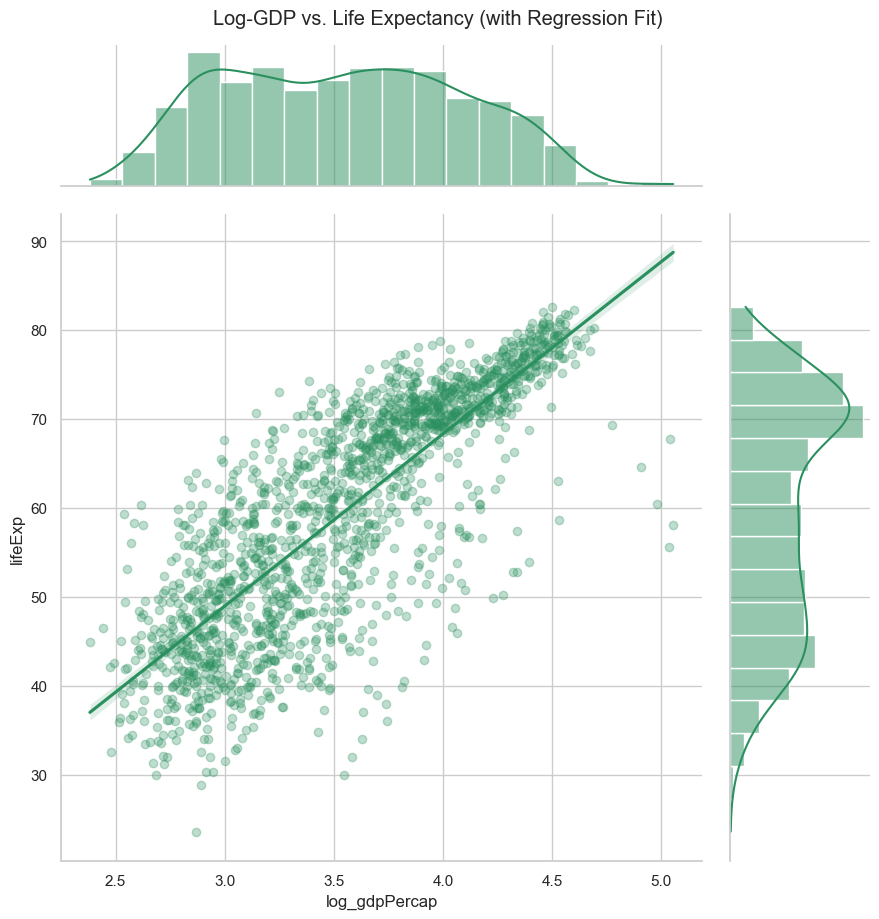

In [16]:
# Chart 3: Regression Plot with Marginal Distributions
g = sns.jointplot(data=df_clean, x="log_gdpPercap", y="lifeExp", kind="reg", 
                  height=9, ratio=4, color="#2b905f", scatter_kws={'alpha': 0.3})
g.fig.suptitle('Log-GDP vs. Life Expectancy (with Regression Fit)', y=1.02)
plt.show()

> **Interpretation:** The regression line (solid) passes through the dense cluster of data points, confirming the model. The marginal histograms on the sides both show that Log-GDP and Life Expectancy are still not normal distribution.

**Regional Divergence (Subplots)** <p>
Which continents are improving consistently? I use small multiples (Facet Grid) to separate the noise.

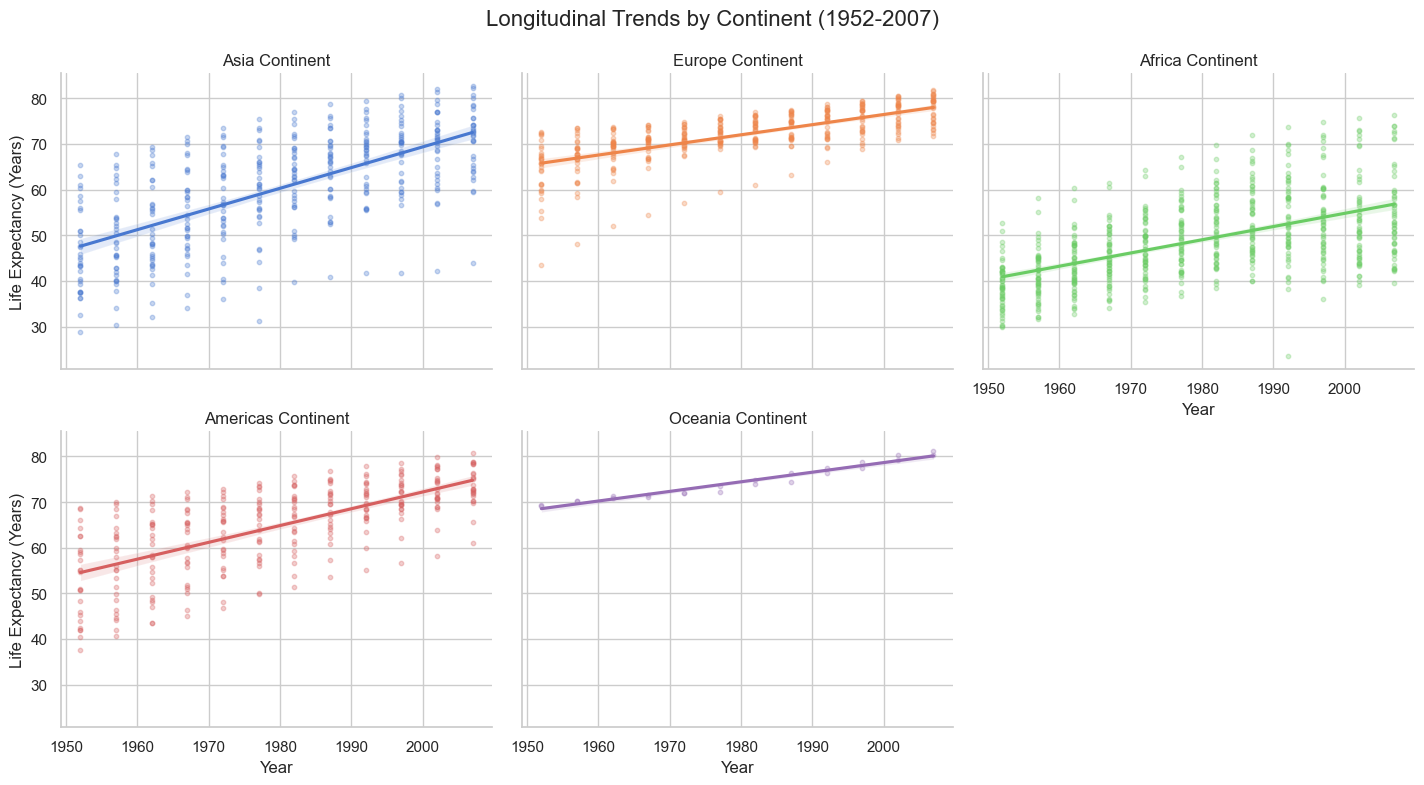

In [17]:
# Chart 4: Regional Facet Grid
g = sns.lmplot(data=df_clean, x="year", y="lifeExp", col="continent", hue="continent", 
               col_wrap=3, height=4, aspect=1.2, scatter_kws={'alpha': 0.3, 's': 10})

# Add titles and adjust layout
g.set_titles("{col_name} Continent")
g.set_axis_labels("Year", "Life Expectancy (Years)")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Longitudinal Trends by Continent (1952-2007)', fontsize=16)
plt.show()

> **Interpretation:** 
> * **Europe/Oceania:** Started high and stayed high with slow, steady growth.
> * **Asia:** Shows the steepest slope, indicating the fastest "catch-up" (Rapid development).
> * **Africa:** Shows a flattening trend (and even a dip in some countries) around the 1990s, visually capturing the stagnation discussed in the hypothesis.

**Visualizing Growth Velocity (Interactive)** <p>
Using the results from the Pivot Table in Section 4, and visualize exactly how much each region grew.

In [18]:
# Data from Section 4 Pivot Table
# Note: Ensure 'regional_progress' is defined from previous cells or recreate it here for safety
regional_progress_viz = regional_progress.reset_index()

# Chart 5: Interactive Bar Chart of Growth
fig_4 = px.bar(regional_progress_viz, 
             x='continent', 
             y='growth_pct',
             color='growth_pct',
             text_auto='.1f',
             title='Total Percentage Growth in Life Expectancy (1952-2007)',
             labels={'growth_pct': 'Growth (%)', 'continent': 'Region'},
             color_continuous_scale='Viridis',
             template="plotly_white")

fig_4.update_layout(xaxis_title="Continent", yaxis_title="Percentage Growth")
fig_4.show()
fig_4.write_html("Total Percentage Growth in Life Expectancy (1952-2007)_plot.html", include_plotlyjs=True, full_html=True)

> **Interpretation:** **Asia** is the clear winner of the "Catch-Up" race with over **60% growth** in life expectancy, double that of the Americas. This confirms the "Asian Miracle" of the late 20th century.

**The 2007 Inequality Snapshot** <p>
Finally, looking at the distribution of the most recent data to understand the current state of global inequality.

/var/folders/fl/f_hjv3lj25z58v5bn3btbssh0000gn/T/ipykernel_21840/3229293207.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




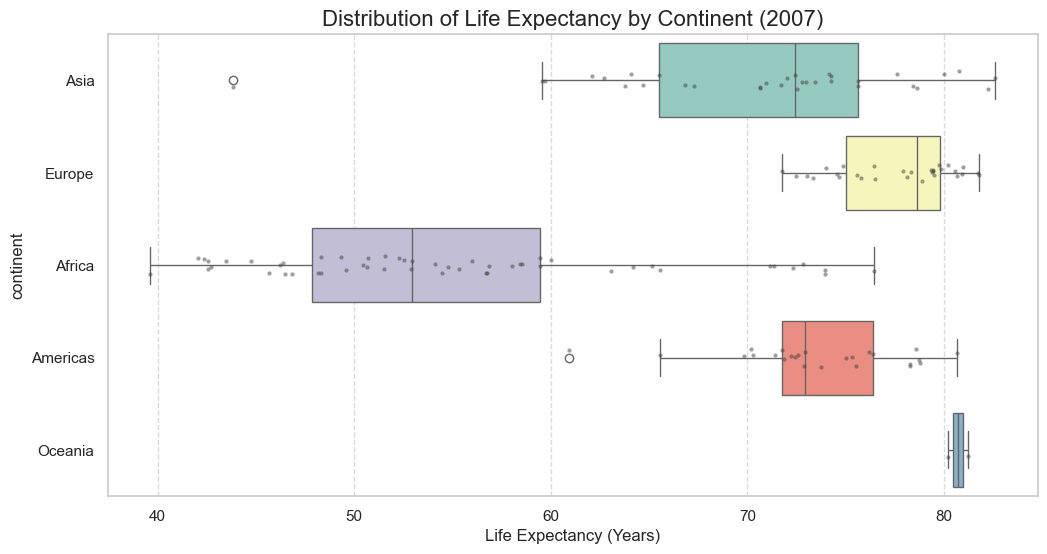

In [19]:
# Chart 6: Boxplot of 2007 Data
plt.figure(figsize=(12, 6))
data_2007 = df_clean[df_clean['year'] == 2007]

sns.boxplot(x='lifeExp', y='continent', data=data_2007, palette="Set3")
sns.stripplot(x='lifeExp', y='continent', data=data_2007, color=".25", alpha=0.5, size=3)

plt.title('Distribution of Life Expectancy by Continent (2007)', fontsize=16)
plt.xlabel('Life Expectancy (Years)')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

> **Interpretation:** 
> * **Africa** has the widest spread and the lowest median, confirming it is the region with the most internal inequality and challenges.
> * **Europe and Oceania** are highly compacted at the top, meaning almost everyone in those regions enjoys a long life (low inequality).

## Section 6 - Conclusions

### 6.1 Research Question Answers & Quantified Insights
This analysis successfully demonstrated the strong but non-linear relationship between economic output and human longevity.

* **RQ1 (The Wealth-Health Link):** A strong positive correlation (**r = 0.81**) was observed between `log_gdpPercap` and `lifeExp`. The regression model confirms a "diminishing returns" effect, i.e., while early economic gains drastically improve health, the benefits plateau after a nation reaches approximately **$5,000 GDP per capita**.
* **RQ2 (Temporal Shifts):** The world is living longer. From 1952 to 2007, the global weighted average life expectancy rose significantly. The "Hans Rosling" visualization revealed that while the entire world moved "up and to the right," the **wealth gap** (skewness) remains persistent.
* **RQ3 (Regional Catch-Up):** **Asia** demonstrated the most remarkable velocity, achieving over **60% growth** in life expectancy, effectively "catching up" to the West. In contrast, **Africa** showed signs of stagnation in the 1990s (likely due to the HIV/AIDS epidemic), creating a distinct "negative tail" in the global distribution.

### 6.2 Limitations & Methodology Reflection
While the results are robust, the following limitations must be acknowledged:
* **Data Age:** The dataset concludes in **2007**. It fails to capture significant modern events like the 2008 financial crisis or the COVID-19 pandemic, limiting current predictive power.
* **Proxy Limitations:** Using GDP as a sole proxy for "wealth" ignores income inequality *within* countries (Gini coefficient). A country can be "rich" on average while its population remains poor.
* **Causality:** Correlation does not imply causation. While wealth helps health, healthier populations also produce more wealth (reverse causality).

### 6.3 Actionable Recommendations & Future Work
* **Policy Focus:** International health aid yields the highest marginal return in nations with GDP under **$3,000**. Beyond this threshold, focus should shift to lifestyle-related health factors rather than basic economic aid.
* **Future Improvement:** A stronger model would incorporate **Education Index** and **Healthcare Spending** columns to create a Multiple Regression model, likely increasing our $R^2$ value beyond 0.65. (Explanability)

## Section 7 - AI Log

| Project Phase | Specific Usage Description |
| :--- | :--- |
| **1. Ideation & Strategy** | Consulted AI to refine the initial research questions, shifting focus from simple trends to "Regional Divergence" and "Wealth-Health Correlation" to meet the "Above and Beyond" criteria. |
| **2. Data Cleaning** | Used AI to generate the `detect_health_outliers` function and to verify the logic behind using a Logarithmic Transformation for the skewed GDP data. |
| **3. Coding & Debugging** | Requested AI assistance to write the complex syntax for the **Plotly Interactive Animation** (Bubble Chart) and the **Weighted Mean** aggregation function, ensuring the code followed DRY (Don't Repeat Yourself) principles. |
| **4. Analysis & Writing** | Used AI to help structure the academic tone of the Introduction and Conclusion sections. The specific statistical interpretations (e.g., analyzing skewness shifts over time) were brainstormed with AI assistance. |

> I have reviewed all code suggestions provided by the AI to ensure I understand their functionality. 

### Export PDF

In [20]:
import plotly.io as pio
pio.renderers.default = "notebook_connected" 


# python -m jupyter nbconvert --to webpdf --embed-images --allow-chromium-download TingYi_KAO-FinalProject.ipynb

### Export Interactive Plots

In [21]:
import plotly.io as pio
figs = [fig_2, fig_4]  # Add other figures as needed
parts = []
for i, fig in enumerate(figs):
    parts.append(
        pio.to_html(
            fig,
            full_html=False,
            include_plotlyjs="inline" if i == 0 else False,  # 只在第一張內嵌 plotly.js
        )
    )